# 05 — Individual PV-Tendency Terms & Bootstrap Significance

This notebook projects **8 individual** PV-tendency terms onto the four-basis decomposition
(basis from **dh−1**, predictive framing) and uses **bootstrap resampling** for confidence
intervals and significance testing.

Terms: dq/dt, −ū q'_x, −v' q̄_y, −ω' q̄_p, Q, Moist div + vert e-e, Rot. eddy, **Tot. div outflow**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.decomposition.basis import PRENORM_PHI1

# ═══════════════════════════════════════════════════════════
#  Projection masking config (toggle on/off)
# ═══════════════════════════════════════════════════════════
USE_SIG_MASK   = True   # zero out non-significant pixels before projection
USE_NEG_PV_MASK = True  # restrict basis to q' < 0 region (mask_negative)

## 1  Discover and load all event files

In [2]:
DATA_ROOT = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE = "onset"
DH = 0
SMOOTH_DEG = 3.0
GRID_SP = 1.5

# Basis always from dh-1 (predictive framing)
DH_BASIS = max(DH - 1, -13)

sign = "+" if DH >= 0 else ""
npz_dir = f"{DATA_ROOT}/{STAGE}/dh={sign}{DH}"
npz_files = sorted(glob.glob(os.path.join(npz_dir, "track_*.npz")))

sign_b = "+" if DH_BASIS >= 0 else ""
npz_dir_b = f"{DATA_ROOT}/{STAGE}/dh={sign_b}{DH_BASIS}"
npz_files_b = sorted(glob.glob(os.path.join(npz_dir_b, "track_*.npz")))

print(f"Stage: {STAGE}   DH={DH} ({len(npz_files)} files)   "
      f"DH_BASIS={DH_BASIS} ({len(npz_files_b)} files)   "
      f"Smoothing: {SMOOTH_DEG}°")

Stage: onset   DH=0 (1052 files)   DH_BASIS=-1 (1052 files)   Smoothing: 3.0°


In [3]:
from zipfile import BadZipFile

def load_event(path):
    """Load an NPZ file and return a dict (None if corrupt/incomplete)."""
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None

def _load_all(file_list, label=""):
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(load_event, file_list))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ {label}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good

# Load events at DH (fields to project)
events = _load_all(npz_files, f"dh={DH}")
print(f"dh={DH}: {len(events)} events, shape={events[0]['pv_anom'].shape}")

# Load events at DH-1 (for basis construction)
events_basis = _load_all(npz_files_b, f"dh={DH_BASIS}")
print(f"dh={DH_BASIS} (basis): {len(events_basis)} events")

X_rel = events[0]["X_rel"]
Y_rel = events[0]["Y_rel"]
x_rel = X_rel[0, :]
y_rel = Y_rel[:, 0]

dh=0: 1052 events, shape=(29, 49)
dh=-1 (basis): 1052 events


## 2  Compute composite-mean basis fields (from dh−1)

In [4]:
# Average PV anomaly and its derivatives from dh-1 events (predictive framing)
pv_anom_mean = np.nanmean([e["pv_anom"] for e in events_basis], axis=0)
pv_dx_mean   = np.nanmean([e["pv_anom_dx"] for e in events_basis], axis=0)
pv_dy_mean   = np.nanmean([e["pv_anom_dy"] for e in events_basis], axis=0)

basis = compute_orthogonal_basis(
    pv_anom_mean, pv_dx_mean, pv_dy_mean,
    x_rel, y_rel,
    mask_negative=USE_NEG_PV_MASK,
    apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
)
print(f"Composite basis (from dh={DH_BASIS}) norms:",
      {k: f"{v:.4e}" for k, v in basis.norms.items()})
print(f"  mask_negative={USE_NEG_PV_MASK}  USE_SIG_MASK={USE_SIG_MASK}")

Composite basis (from dh=-1) norms: {'beta': '6.7848e+02', 'ax': '9.3380e+02', 'ay': '9.2497e+02', 'gamma': '5.0456e+02'}
  mask_negative=True  USE_SIG_MASK=True


## 3  Define individual RHS terms

In [5]:
# Term name → callable(event_dict) → 2-D field
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":        lambda e: e["pv_anom_dt"] + e["pv_bar_dt"],
    r"$-\bar{u}\,q'_x$":                  lambda e: -e["u_bar_pv_anom_dx"],
    r"$-v'\,\bar{q}_y$":                  lambda e: -e["v_anom_pv_bar_dy"],
    r"$-\omega\,\bar{q}_p$":             lambda e: -(e["w_anom_pv_bar_dp"]
                                                       + e["w_bar_pv_bar_dp"]),
    r"$Q$":                                lambda e: e["Q"],
    r"Moist div":                       lambda e: -(e["u_div_moist_pv_anom_dx"]
                                                       + e["v_div_moist_pv_anom_dy"]),
    r"Dry div":                       lambda e: -(e["u_div_dry_pv_anom_dx"]
                                                       + e["v_div_dry_pv_anom_dy"]),
    r"$-\omega_m\,q'_p$":                         lambda e: -(e["w_moist_pv_anom_dp"]),
    r"Rot. eddy":                          lambda e: -(e["u_rot_pv_anom_dx"]
                                                       + e["v_rot_pv_anom_dy"]),
    # r"Tot. div outflow":                   lambda e: -(e["u_div_pv_anom_dx"]
    #                                                    + e["v_div_pv_anom_dy"]),
}

TERM_NAMES = list(TERMS.keys())
print("Terms:", TERM_NAMES)

Terms: ['$\\mathrm{d}q/\\mathrm{d}t$', "$-\\bar{u}\\,q'_x$", "$-v'\\,\\bar{q}_y$", '$-\\omega\\,\\bar{q}_p$', '$Q$', 'Moist div', 'Dry div', "$-\\omega_m\\,q'_p$", 'Rot. eddy']


## 4  Project composite-mean terms onto dh−1 basis

In [6]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# ── Bootstrap field helper (for sig_mask) ──
def bootstrap_field(events_list, field_func, n_boot=1000, alpha=0.05, seed=42):
    """Composite mean + bootstrap CI → (mean, sig_mask)."""
    stack = np.array([field_func(e) for e in events_list])
    N = stack.shape[0]
    rng = np.random.default_rng(seed)
    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)
    lo = np.nanpercentile(boot, 100 * alpha / 2, axis=0)
    hi = np.nanpercentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask

# ── Composite-mean projection of each term ──
# If USE_SIG_MASK: compute composite sig_mask per term, zero non-sig pixels
term_coefs = {}
term_sig_masks = {}
for name, func in TERMS.items():
    if USE_SIG_MASK:
        fld_mean, sig_m = bootstrap_field(events, func)
        term_sig_masks[name] = sig_m
        fld_masked = np.where(sig_m, fld_mean, 0.0)
        fld_s = smooth(fld_masked)
    else:
        fld_mean = np.nanmean([func(e) for e in events], axis=0)
        fld_s = smooth(fld_mean)
    p = project_field(fld_s, basis)
    term_coefs[name] = {k: p[k] for k in ["beta", "ax", "ay", "gamma"]}
    print(f"{name:30s}  β={p['beta']:.3e}  αx={p['ax']:.3f}  "
          f"αy={p['ay']:.3f}  γ={p['gamma']:.3e}")
print(f"\n  [USE_SIG_MASK={USE_SIG_MASK}]")

$\mathrm{d}q/\mathrm{d}t$       β=3.179e-06  αx=5.420  αy=2.489  γ=-1.971e+05
$-\bar{u}\,q'_x$                β=7.771e-09  αx=16.413  αy=-0.334  γ=-2.455e+06
$-v'\,\bar{q}_y$                β=5.248e-07  αx=-7.306  αy=0.267  γ=1.452e+06
$-\omega\,\bar{q}_p$            β=7.085e-07  αx=-4.786  αy=1.603  γ=1.534e+06
$Q$                             β=1.595e-07  αx=-0.087  αy=-0.003  γ=4.268e+04
Moist div                       β=8.000e-07  αx=-0.679  αy=-0.138  γ=-1.804e+04
Dry div                         β=2.611e-07  αx=0.086  αy=-0.063  γ=6.973e+04
$-\omega_m\,q'_p$               β=-8.752e-07  αx=0.836  αy=-0.319  γ=-1.674e+05
Rot. eddy                       β=1.270e-06  αx=0.760  αy=0.823  γ=-1.476e+05

  [USE_SIG_MASK=True]


## 5  Bootstrap resampling for significance

In [7]:
N_BOOT = 1000
rng = np.random.default_rng(42)
n_events = len(events)

def bootstrap_term(name, func, n_boot=N_BOOT):
    """Bootstrap the projected coefficients for one term.

    If USE_SIG_MASK: per-event field is masked by the composite sig_mask
    (same approach as notebook 07's bootstrap_project).
    """
    # Get sig_mask for this term (compute if not already cached)
    if USE_SIG_MASK:
        if name in term_sig_masks:
            sig_m = term_sig_masks[name]
        else:
            _, sig_m = bootstrap_field(events, func)
            term_sig_masks[name] = sig_m

    # Per-event projections (dh=DH fields onto dh-1 basis)
    per_event = []
    for e in events:
        raw = func(e)
        if USE_SIG_MASK:
            raw = np.where(sig_m, raw, 0.0)
        field_s = smooth(raw)
        p = project_field(field_s, basis)
        per_event.append({k: p[k] for k in ["beta", "ax", "ay", "gamma"]})

    per_event_arr = {k: np.array([pe[k] for pe in per_event])
                     for k in ["beta", "ax", "ay", "gamma"]}

    # Bootstrap
    boot = {k: np.empty(n_boot) for k in ["beta", "ax", "ay", "gamma"]}
    for b in range(n_boot):
        idx = rng.integers(0, n_events, size=n_events)
        for k in boot:
            boot[k][b] = per_event_arr[k][idx].mean()

    return boot

print(f"Running bootstrap (USE_SIG_MASK={USE_SIG_MASK})...")
boot_results = {}
for name, func in TERMS.items():
    boot_results[name] = bootstrap_term(name, func)
    lo, hi = np.nanpercentile(boot_results[name]["beta"], [2.5, 97.5])
    sig = "***" if lo * hi > 0 else "n.s."
    print(f"  {name:30s}  β 95% CI: [{lo:.3e}, {hi:.3e}]  {sig}")

Running bootstrap (USE_SIG_MASK=True)...
  $\mathrm{d}q/\mathrm{d}t$       β 95% CI: [2.825e-06, 3.510e-06]  ***
  $-\bar{u}\,q'_x$                β 95% CI: [-3.855e-07, 3.660e-07]  n.s.
  $-v'\,\bar{q}_y$                β 95% CI: [2.811e-07, 7.240e-07]  ***
  $-\omega\,\bar{q}_p$            β 95% CI: [4.351e-07, 9.595e-07]  ***
  $Q$                             β 95% CI: [1.492e-07, 1.693e-07]  ***
  Moist div                       β 95% CI: [7.198e-07, 8.806e-07]  ***
  Dry div                         β 95% CI: [2.158e-07, 3.039e-07]  ***
  $-\omega_m\,q'_p$               β 95% CI: [-9.745e-07, -7.786e-07]  ***
  Rot. eddy                       β 95% CI: [1.074e-06, 1.453e-06]  ***


## 6  Visualise bootstrap results

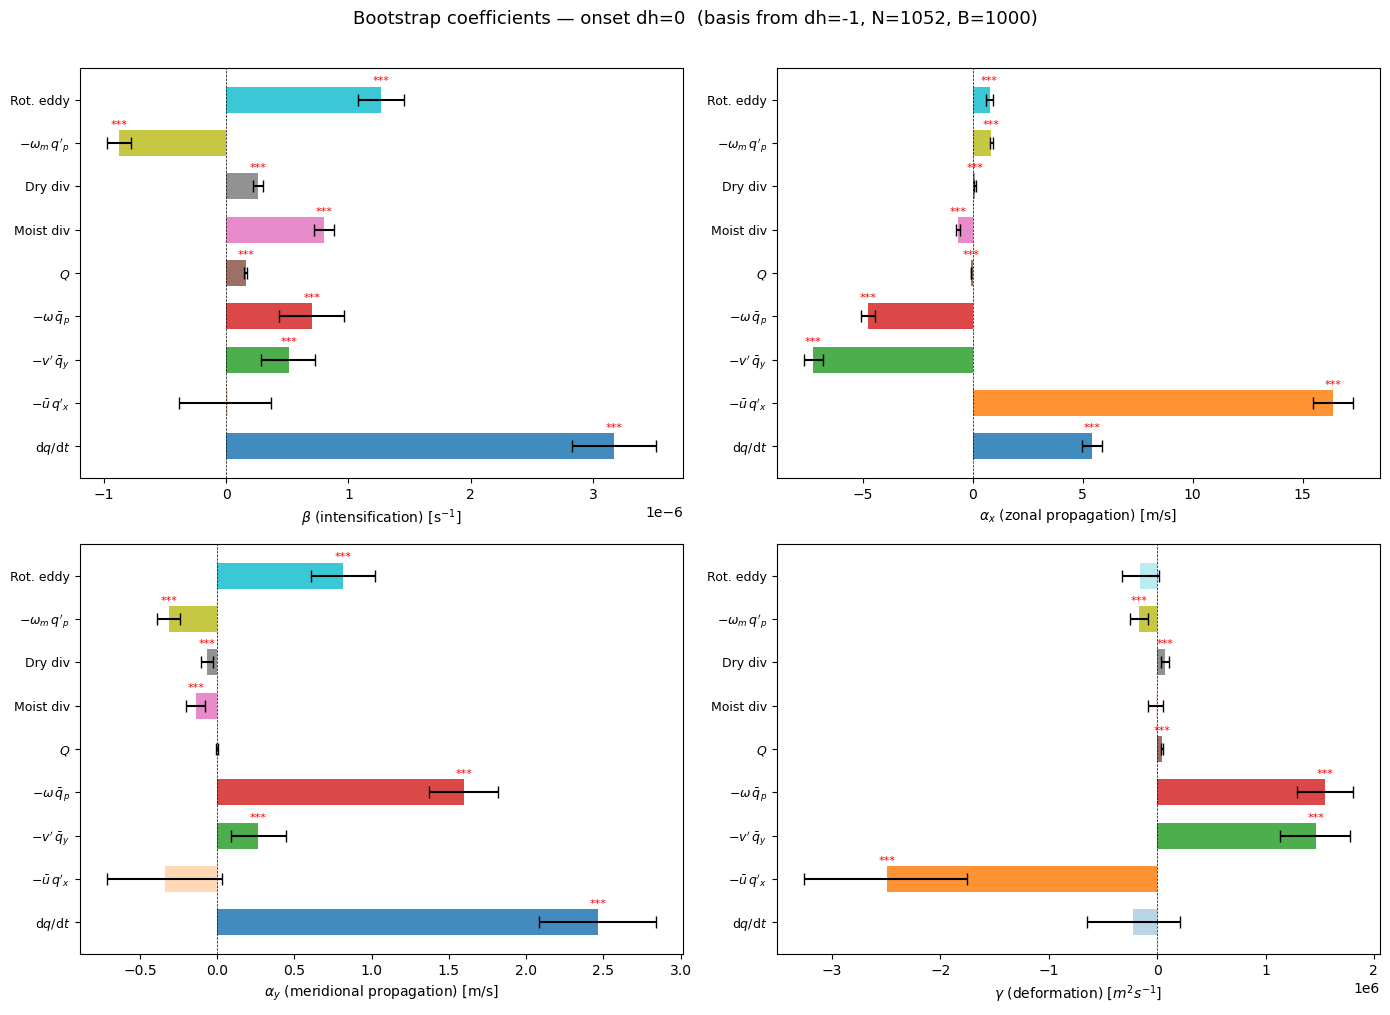

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
coef_names = ["beta", "ax", "ay", "gamma"]
coef_labels = [r"$\beta$ (intensification) [s$^{-1}$]",
               r"$\alpha_x$ (zonal propagation) [m/s]",
               r"$\alpha_y$ (meridional propagation) [m/s]",
               r"$\gamma$ (deformation) [$m^2s^{-1}$]"]

n_terms = len(TERMS)
colors = plt.cm.tab10(np.linspace(0, 1, n_terms))

for ax, cname, clabel in zip(axes.flat, coef_names, coef_labels):
    for i, (tname, bdata) in enumerate(boot_results.items()):
        vals = bdata[cname]
        mean = vals.mean()
        lo, hi = np.nanpercentile(vals, [2.5, 97.5])
        sig = lo * hi > 0  # CI excludes zero?

        ax.barh(i, mean, xerr=[[mean - lo], [hi - mean]],
                color=colors[i],
                alpha=0.85 if sig else 0.3,
                capsize=4, height=0.6)
        if sig:
            ax.text(mean, i + 0.35, "***", ha="center", fontsize=8, color="red")

    ax.set_yticks(range(n_terms))
    ax.set_yticklabels(TERM_NAMES, fontsize=9)
    ax.axvline(0, color="k", lw=0.5, ls="--")
    ax.set_xlabel(clabel, fontsize=10)

fig.suptitle(f"Bootstrap coefficients — {STAGE} dh={DH}  "
             f"(basis from dh={DH_BASIS}, N={n_events}, B={N_BOOT})",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Summary

- **8 individual PV-tendency terms** are projected onto the four-basis decomposition:
  dq/dt, −ū q'_x, −v' q̄_y, −ω' q̄_p, Q, Moist div + vert e-e, Rot. eddy, Tot. div outflow.
- Basis built from **dh−1** composite mean (predictive framing), 6° Gaussian smoothing.
- **Bootstrap resampling** (N=1000) provides 95 % confidence intervals;
  bars are opaque when the CI excludes zero (significant at p < 0.05).
- **Data**: `composite_blocking_tempest/onset`.

## 7  Closure check: full advection budget

Verify that the **12 advection cross-terms** plus diabatic heating $Q$ close
the PV budget:

$$
\underbrace{\frac{\partial q'}{\partial t}
+ \frac{\partial \bar{q}}{\partial t}}_{\text{LHS (tendency)}}
\;\approx\;
\underbrace{-\sum_{i \in \{u,v,\omega\}}
\sum_{j \in \{\text{bar,anom}\}}
\sum_{k \in \{\text{bar,anom}\}}
j_i \;\frac{\partial k_q}{\partial x_i}
\;+\; Q}_{\text{RHS (advection + diabatic)}}
$$

Residual = LHS − RHS is bootstrapped; hatching marks grid points where
the 1.5 σ CI on the residual **excludes zero** (significant imbalance).

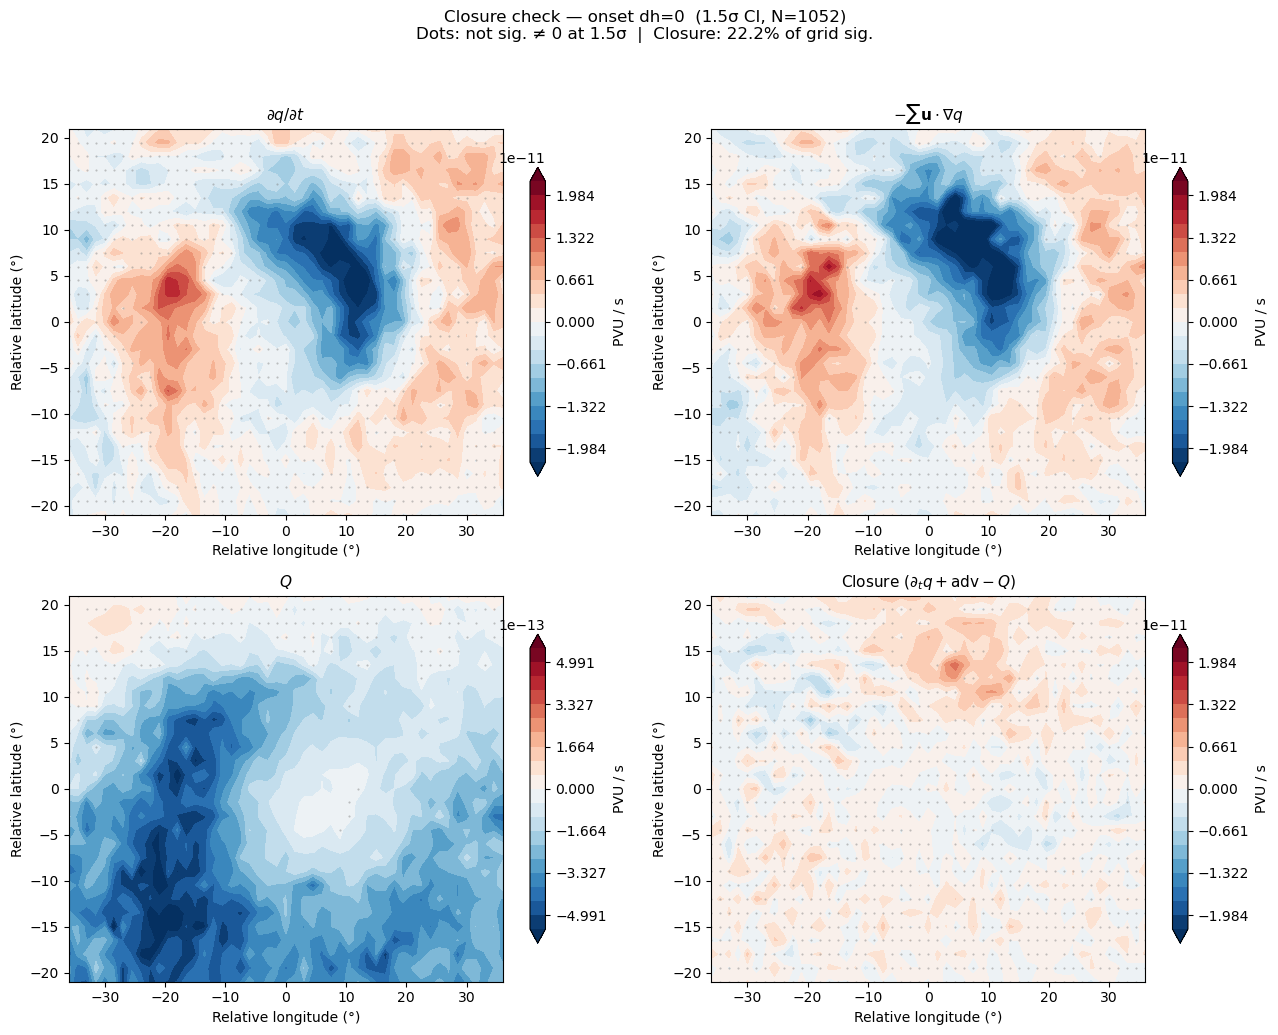

Mean |residual|:  1.877e-12
Mean |dq/dt|:     4.651e-12
Mean |rel. res|:  202.3%
Grid points with sig. imbalance (1.5σ): 316/1421 (22.2%)


In [14]:
# ── All 12 advection cross-terms (negated, since they appear as -adv on RHS) ──
ADV_KEYS = [
    "u_bar_pv_anom_dx",  "u_bar_pv_bar_dx",
    "u_anom_pv_anom_dx", "u_anom_pv_bar_dx",
    "v_bar_pv_anom_dy",  "v_bar_pv_bar_dy",
    "v_anom_pv_anom_dy", "v_anom_pv_bar_dy",
    "w_bar_pv_anom_dp",  "w_bar_pv_bar_dp",
    "w_anom_pv_anom_dp", "w_anom_pv_bar_dp",
]

def _lhs(e):
    """LHS = dq'/dt + dq̄/dt."""
    return e["pv_anom_dt"] + e["pv_bar_dt"]

def _neg_adv(e):
    """Negated sum of 12 advection cross-terms."""
    return -sum(e[k] for k in ADV_KEYS)

def _Q(e):
    return e["Q"]

def _residual(e):
    """Closure residual = dq/dt + Σ(adv) − Q."""
    return _lhs(e) + sum(e[k] for k in ADV_KEYS) - e["Q"]

# ── Bootstrap all four fields ──
from scipy.stats import norm

N_BOOT_CL = 1000
rng_cl = np.random.default_rng(99)
n_ev = len(events)

panel_funcs = {
    r"$\partial q/\partial t$": _lhs,
    r"$-\sum \mathbf{u}\cdot\nabla q$": _neg_adv,
    r"$Q$": _Q,
    r"Closure ($\partial_t q + \mathrm{adv} - Q$)": _residual,
}

p_lo = norm.cdf(-1.5) * 100  # ≈ 6.68
p_hi = norm.cdf( 1.5) * 100  # ≈ 93.32

panel_data = {}  # name → (mean, sig_mask)
for name, func in panel_funcs.items():
    stack = np.array([func(e) for e in events])
    mean = np.nanmean(stack, axis=0)
    boot = np.empty((N_BOOT_CL, *mean.shape))
    for b in range(N_BOOT_CL):
        idx = rng_cl.integers(0, n_ev, size=n_ev)
        boot[b] = np.nanmean(stack[idx], axis=0)
    ci_lo = np.nanpercentile(boot, p_lo, axis=0)
    ci_hi = np.nanpercentile(boot, p_hi, axis=0)
    sig = ~((ci_lo <= 0) & (ci_hi >= 0))
    panel_data[name] = (mean, sig)

# ── Colour scales: shared for dq/dt, adv, closure; separate for Q ──
panel_names = list(panel_funcs.keys())
shared_names = [n for n in panel_names if n != r"$Q$"]
vmax_shared = max(np.nanpercentile(np.abs(panel_data[n][0]), 98)
                  for n in shared_names)
vmax_Q = np.nanpercentile(np.abs(panel_data[r"$Q$"][0]), 98)

# Explicitly symmetric levels
N_LEV = 21
levs_shared = np.linspace(-vmax_shared, vmax_shared, N_LEV)
levs_Q      = np.linspace(-vmax_Q, vmax_Q, N_LEV)

# ── Plot 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, name in zip(axes.flat, panel_names):
    mean, sig = panel_data[name]
    levs = levs_Q if name == r"$Q$" else levs_shared
    cf = ax.contourf(X_rel, Y_rel, mean, levels=levs,
                     cmap="RdBu_r", extend="both")
    # Dot non-significant regions
    not_sig = ~sig
    if not_sig.any():
        ax.plot(X_rel[not_sig], Y_rel[not_sig], '.', color='grey',
                markersize=1.0, alpha=0.5)
    plt.colorbar(cf, ax=ax, shrink=0.8, label="PVU / s")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Relative longitude (°)")
    ax.set_ylabel("Relative latitude (°)")

res_mean, res_sig = panel_data[panel_names[-1]]
frac_sig = res_sig.sum() / res_sig.size * 100
fig.suptitle(f"Closure check — {STAGE} dh={DH}  (1.5σ CI, N={n_ev})\n"
             f"Dots: not sig. ≠ 0 at 1.5σ  |  Closure: {frac_sig:.1f}% of grid sig.",
             fontsize=12, y=1.03)
fig.tight_layout()
plt.show()

# ── Summary stats ──
lhs_mean = panel_data[panel_names[0]][0]
print(f"Mean |residual|:  {np.nanmean(np.abs(res_mean)):.3e}")
print(f"Mean |dq/dt|:     {np.nanmean(np.abs(lhs_mean)):.3e}")
print(f"Mean |rel. res|:  {np.nanmean(np.abs(res_mean / (np.abs(lhs_mean) + 1e-30))) * 100:.1f}%")
print(f"Grid points with sig. imbalance (1.5σ): "
      f"{res_sig.sum()}/{res_sig.size} ({frac_sig:.1f}%)")